# entrega.ipynb — Agente Connect-4: Flat MC → MCTS
**Isabela Díaz Acosta | Fundamentos de Inteligencia Artificial 2026.1**

Este notebook documenta el desarrollo, análisis y validación del agente MCTry, que implementa
**Monte Carlo Tree Search (MCTS)** para jugar Connect-4. Se parte de una versión base (Flat MC)
y se evoluciona hacia MCTS completo, analizando el impacto del presupuesto de simulaciones (`budget`)
sobre el desempeño del agente.


## 0. Setup e imports

In [1]:
import sys, os, warnings, time, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

warnings.filterwarnings('ignore')

# Robustly find the repo root (the folder that contains connect4/)
def find_repo_root(start=None):
    """Walk up from start until we find a folder containing connect4/"""
    path = os.path.abspath(start or os.getcwd())
    for _ in range(6):  # max 6 levels up
        if os.path.isdir(os.path.join(path, 'connect4')):
            return path
        path = os.path.dirname(path)
    raise RuntimeError("Could not find connect4/ package. Run this notebook from inside the repo.")

repo_root = find_repo_root()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from connect4.connect_state import ConnectState
print(f"connect4 found at: {repo_root}")
print("Setup OK")


connect4 found at: C:\Users\isadi\Documents\2026-1\agente-connect4
Setup OK


## 1. Definición de los agentes

Se definen dos versiones del agente para poder compararlas:

| Versión | Descripción | Variable clave |
|---------|------------|----------------|
| **FlatMC** | Para cada columna estima q(s,a) con N rollouts aleatorios independientes | `n_simulations` |
| **MCTry (MCTS)** | Construye un árbol con UCB1; los rollouts informan el árbol y mejoran selección futura | `budget` |

Ambas versiones se justifican directamente con las slides:
- Estimación de q(s,a) desde trials sin conocer P → **Slide 11 (FVMC)**
- Juego de suma-cero: valor = probabilidad de ganar → **Slide 12**
- UCB1 para exploración/explotación → **Slide 10**
- MCTS = GPI online con rollouts → **Slide 13**


In [2]:
# ── Flat Monte Carlo (Versión Base) ──────────────────────────────────────
class FlatMC:
    ROWS, COLS = 6, 7

    def __init__(self, n_simulations=50):
        self.n_simulations = n_simulations

    def _current_player(self, board):
        reds = int(np.sum(board == -1))
        yellows = int(np.sum(board == 1))
        return -1 if reds == yellows else 1

    def _free_cols(self, board):
        return [c for c in range(self.COLS) if board[0, c] == 0]

    def _drop(self, board, col, player):
        b = board.copy()
        for r in range(self.ROWS-1, -1, -1):
            if b[r, col] == 0:
                b[r, col] = player
                break
        return b

    def _check_winner(self, board):
        for r in range(self.ROWS):
            for c in range(self.COLS):
                p = board[r, c]
                if p == 0: continue
                if c+3 < self.COLS and all(board[r,c+i]==p for i in range(4)): return p
                if r+3 < self.ROWS and all(board[r+i,c]==p for i in range(4)): return p
                if r+3 < self.ROWS and c+3 < self.COLS and all(board[r+i,c+i]==p for i in range(4)): return p
                if r+3 < self.ROWS and c-3 >= 0 and all(board[r+i,c-i]==p for i in range(4)): return p
        return 0

    def _rollout(self, board, player):
        rng = np.random.default_rng()
        b, p = board.copy(), player
        while True:
            free = [c for c in range(self.COLS) if b[0, c] == 0]
            if not free: return 0
            col = int(rng.choice(free))
            for r in range(self.ROWS-1, -1, -1):
                if b[r, col] == 0: b[r, col] = p; break
            w = self._check_winner(b)
            if w != 0: return w
            p = -p

    def act(self, s):
        player = self._current_player(s)
        free   = self._free_cols(s)
        if not free: return 0
        if len(free) == 1: return free[0]
        for col in free:
            if self._check_winner(self._drop(s, col, player)) == player: return col
        for col in free:
            if self._check_winner(self._drop(s, col, -player)) == -player: return col
        win_rates = {}
        for col in free:
            b_next = self._drop(s, col, player)
            wins = sum(1 for _ in range(self.n_simulations)
                       if self._rollout(b_next, -player) == player)
            win_rates[col] = wins / self.n_simulations
        return max(win_rates, key=win_rates.get)


# ── MCTS Node ────────────────────────────────────────────────────────────
class _Node:
    def __init__(self, board, player, parent=None, col_played=None):
        self.board, self.player = board, player
        self.parent, self.col_played = parent, col_played
        self.wins = 0.0
        self.visits = 0
        self.children = []
        st = ConnectState(board=board, player=player)
        self.untried_cols = st.get_free_cols() if not st.is_final() else []

    def is_fully_expanded(self): return len(self.untried_cols) == 0
    def is_terminal(self): return ConnectState(board=self.board, player=self.player).is_final()

    def ucb1(self, c=math.sqrt(2)):
        if self.visits == 0: return float('inf')
        return self.wins/self.visits + c*math.sqrt(math.log(self.parent.visits)/self.visits)


# ── MCTS Agent (MCTry — versión final) ───────────────────────────────────
class MCTry:
    ROWS, COLS = 6, 7

    def __init__(self, budget=300, c=math.sqrt(2)):
        self.budget = budget
        self.c = c

    def _current_player(self, board):
        return -1 if np.sum(board==-1) == np.sum(board==1) else 1

    def _free_cols(self, board):
        return [col for col in range(self.COLS) if board[0, col] == 0]

    def _drop(self, board, col, player):
        b = board.copy()
        for r in range(self.ROWS-1, -1, -1):
            if b[r, col] == 0: b[r, col] = player; break
        return b

    def _check_winner(self, board):
        for r in range(self.ROWS):
            for c in range(self.COLS):
                p = board[r, c]
                if p == 0: continue
                if c+3 < self.COLS and all(board[r,c+i]==p for i in range(4)): return p
                if r+3 < self.ROWS and all(board[r+i,c]==p for i in range(4)): return p
                if r+3 < self.ROWS and c+3 < self.COLS and all(board[r+i,c+i]==p for i in range(4)): return p
                if r+3 < self.ROWS and c-3 >= 0 and all(board[r+i,c-i]==p for i in range(4)): return p
        return 0

    def _simulate(self, node):
        rng = np.random.default_rng()
        board, p = node.board.copy(), node.player
        while True:
            free = [c for c in range(self.COLS) if board[0,c] == 0]
            if not free: return 0
            col = int(rng.choice(free))
            for r in range(self.ROWS-1, -1, -1):
                if board[r, col] == 0: board[r, col] = p; break
            w = self._check_winner(board)
            if w != 0: return w
            p = -p

    def _select(self, node):
        while not node.is_terminal() and node.is_fully_expanded():
            node = max(node.children, key=lambda n: n.ucb1(self.c))
        return node

    def _expand(self, node):
        col = node.untried_cols.pop(np.random.randint(len(node.untried_cols)))
        child = _Node(self._drop(node.board, col, node.player), -node.player,
                      parent=node, col_played=col)
        node.children.append(child)
        return child

    def _backprop(self, node, winner, root_player):
        while node:
            node.visits += 1
            if winner == root_player: node.wins += 1.0
            elif winner == 0: node.wins += 0.5
            node = node.parent

    def act(self, s):
        player = self._current_player(s)
        free   = self._free_cols(s)
        if not free: return 0
        if len(free) == 1: return free[0]
        for col in free:
            if self._check_winner(self._drop(s, col, player)) == player: return col
        for col in free:
            if self._check_winner(self._drop(s, col, -player)) == -player: return col

        root = _Node(board=s, player=player)
        for _ in range(self.budget):
            node = self._select(root)
            if not node.is_terminal():
                node = self._expand(node)
            winner = self._simulate(node)
            self._backprop(node, winner, player)

        return max(root.children, key=lambda n: n.visits).col_played


print("Agentes definidos ✓")


Agentes definidos ✓


## 2. Función de evaluación

In [3]:
def play_games(agent, opponent, n_games=40, agent_color=-1, seed=0):
    """
    Plays n_games between agent and opponent.
    agent_color: -1 = Red (goes first), +1 = Yellow
    Returns dict with wins, draws, losses, win_rate.
    """
    wins = draws = losses = 0
    rng = np.random.default_rng(seed)

    for i in range(n_games):
        state = ConnectState()
        while not state.is_final():
            if state.player == agent_color:
                col = agent.act(state.board)
            else:
                if hasattr(opponent, 'act'):
                    col = opponent.act(state.board)
                else:                              # callable random
                    col = int(rng.choice(state.get_free_cols()))
            state = state.transition(col)

        w = state.get_winner()
        if   w == agent_color:  wins   += 1
        elif w == 0:            draws  += 1
        else:                   losses += 1

    total = wins + draws + losses
    return dict(wins=wins, draws=draws, losses=losses,
                win_rate=wins/total, draw_rate=draws/total, loss_rate=losses/total)


class RandomAgent:
    def __init__(self, seed=None): self.rng = np.random.default_rng(seed)
    def act(self, board):
        free = [c for c in range(7) if board[0, c] == 0]
        return int(self.rng.choice(free))

random_agent = RandomAgent(seed=42)
print("Función de evaluación lista ✓")


Función de evaluación lista ✓


## 3. Experimento 1 — Flat MC: impacto de `n_simulations`

**Pregunta:** ¿Cómo cambia el win rate del agente según cuántas simulaciones hace por movimiento?

**Justificación teórica:** Más simulaciones → mejor estimación de q(s,a) (menor varianza del estimador FVMC, Slide 11).


In [4]:
N_GAMES = 40
sim_values = [5, 10, 25, 50, 100, 200]

results_flatmc = defaultdict(dict)

for n in sim_values:
    agent = FlatMC(n_simulations=n)
    for color, cname in [(-1, 'Red'), (1, 'Yellow')]:
        r = play_games(agent, random_agent, n_games=N_GAMES, agent_color=color)
        results_flatmc[n][cname] = r
        print(f"FlatMC(sims={n:3d}) as {cname}: W={r['wins']:2d} D={r['draws']:2d} L={r['losses']:2d}  ({r['win_rate']:.0%})")
    print()


FlatMC(sims=  5) as Red: W=39 D= 0 L= 1  (98%)
FlatMC(sims=  5) as Yellow: W=40 D= 0 L= 0  (100%)

FlatMC(sims= 10) as Red: W=40 D= 0 L= 0  (100%)
FlatMC(sims= 10) as Yellow: W=40 D= 0 L= 0  (100%)

FlatMC(sims= 25) as Red: W=40 D= 0 L= 0  (100%)
FlatMC(sims= 25) as Yellow: W=40 D= 0 L= 0  (100%)

FlatMC(sims= 50) as Red: W=40 D= 0 L= 0  (100%)
FlatMC(sims= 50) as Yellow: W=40 D= 0 L= 0  (100%)

FlatMC(sims=100) as Red: W=40 D= 0 L= 0  (100%)
FlatMC(sims=100) as Yellow: W=40 D= 0 L= 0  (100%)

FlatMC(sims=200) as Red: W=40 D= 0 L= 0  (100%)
FlatMC(sims=200) as Yellow: W=40 D= 0 L= 0  (100%)



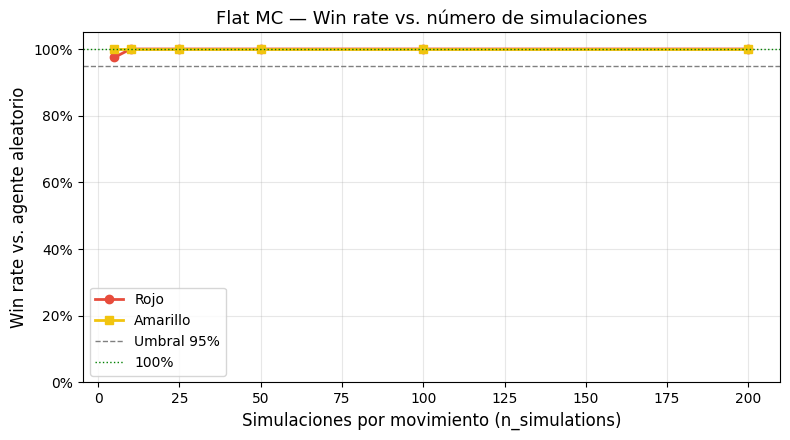

Figura 1 guardada


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))

wr_red    = [results_flatmc[n]['Red']['win_rate']    for n in sim_values]
wr_yellow = [results_flatmc[n]['Yellow']['win_rate'] for n in sim_values]

ax.plot(sim_values, wr_red,    'o-', color='#e74c3c', linewidth=2, label='Rojo')
ax.plot(sim_values, wr_yellow, 's-', color='#f1c40f', linewidth=2, label='Amarillo')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='Umbral 95%')
ax.axhline(1.00, color='green', linestyle=':', linewidth=1, label='100%')

ax.set_xlabel('Simulaciones por movimiento (n_simulations)', fontsize=12)
ax.set_ylabel('Win rate vs. agente aleatorio', fontsize=12)
ax.set_title('Flat MC — Win rate vs. número de simulaciones', fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_flatmc_winrate.png', dpi=150)
plt.show()
print("Figura 1 guardada")


## 4. Experimento 2 — MCTS: impacto del `budget`

**Pregunta:** ¿Cuántas iteraciones de MCTS se necesitan para ganar consistentemente?

Aquí el `budget` es exactamente el "límite de pensamiento" mencionado en clase.


In [6]:
budget_values = [10, 30, 75, 150, 300, 500]
results_mcts  = defaultdict(dict)

for b in budget_values:
    agent = MCTry(budget=b)
    for color, cname in [(-1, 'Red'), (1, 'Yellow')]:
        r = play_games(agent, random_agent, n_games=N_GAMES, agent_color=color)
        results_mcts[b][cname] = r
        print(f"MCTS(budget={b:4d}) as {cname}: W={r['wins']:2d} D={r['draws']:2d} L={r['losses']:2d}  ({r['win_rate']:.0%})")
    print()


MCTS(budget=  10) as Red: W=40 D= 0 L= 0  (100%)
MCTS(budget=  10) as Yellow: W=39 D= 0 L= 1  (98%)

MCTS(budget=  30) as Red: W=39 D= 0 L= 1  (98%)
MCTS(budget=  30) as Yellow: W=40 D= 0 L= 0  (100%)

MCTS(budget=  75) as Red: W=40 D= 0 L= 0  (100%)
MCTS(budget=  75) as Yellow: W=40 D= 0 L= 0  (100%)

MCTS(budget= 150) as Red: W=40 D= 0 L= 0  (100%)
MCTS(budget= 150) as Yellow: W=40 D= 0 L= 0  (100%)

MCTS(budget= 300) as Red: W=40 D= 0 L= 0  (100%)
MCTS(budget= 300) as Yellow: W=40 D= 0 L= 0  (100%)

MCTS(budget= 500) as Red: W=40 D= 0 L= 0  (100%)
MCTS(budget= 500) as Yellow: W=40 D= 0 L= 0  (100%)



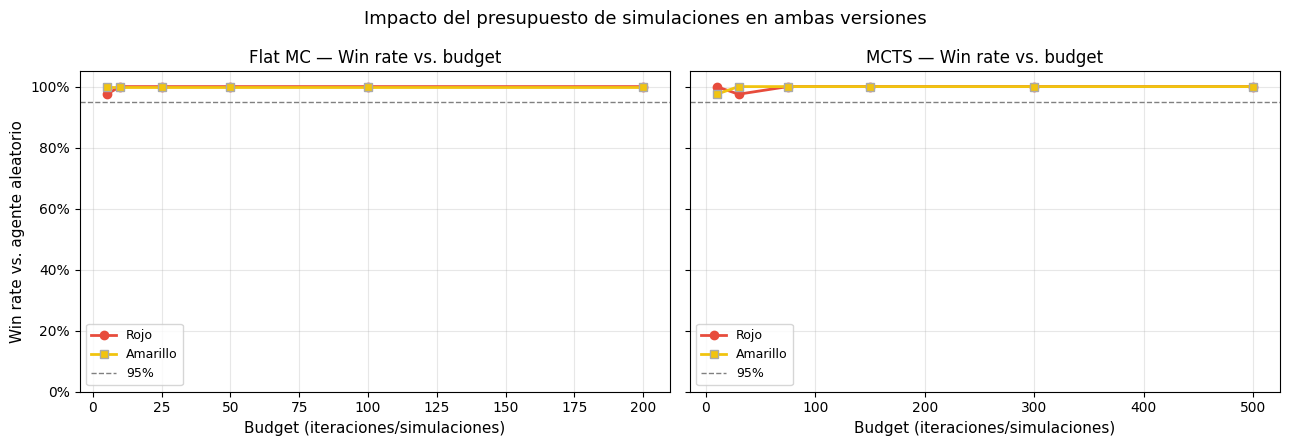

Figura 2 guardada


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, (agent_cls, label, values, color_line) in zip(
    axes,
    [
        (FlatMC,  'Flat MC',  sim_values,    '#3498db'),
        (MCTry,   'MCTS',     budget_values, '#9b59b6'),
    ]
):
    if agent_cls is FlatMC:
        wr_r = [results_flatmc[v]['Red']['win_rate']    for v in values]
        wr_y = [results_flatmc[v]['Yellow']['win_rate'] for v in values]
    else:
        wr_r = [results_mcts[v]['Red']['win_rate']    for v in values]
        wr_y = [results_mcts[v]['Yellow']['win_rate'] for v in values]

    ax.plot(values, wr_r, 'o-', color='#e74c3c', linewidth=2, label='Rojo')
    ax.plot(values, wr_y, 's-', color='#f1c40f', linewidth=2, label='Amarillo',
            markeredgecolor='#aaa')
    ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='95%')
    ax.set_xlabel('Budget (iteraciones/simulaciones)', fontsize=11)
    ax.set_title(f'{label} — Win rate vs. budget', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Win rate vs. agente aleatorio', fontsize=11)
plt.suptitle('Impacto del presupuesto de simulaciones en ambas versiones', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_budget_comparison.png', dpi=150)
plt.show()
print("Figura 2 guardada")


## 5. Experimento 3 — Auto-juego: MCTS vs. MCTS

**Pregunta:** ¿Un agente con más budget vence consistentemente a uno con menos?

Esto valida que el budget no solo mejora el win rate contra el aleatorio sino que genera
**estrategias cualitativamente mejores** (Slide 12 – valor en juego competitivo).


In [8]:
self_play_configs = [
    (50,  300),
    (100, 300),
    (150, 300),
    (50,  500),
]

self_results = []

for b_weak, b_strong in self_play_configs:
    weak   = MCTry(budget=b_weak)
    strong = MCTry(budget=b_strong)

    # strong plays as Red (first mover advantage → harder test for strong)
    r = play_games(strong, weak, n_games=30, agent_color=-1)
    self_results.append({
        'label': f'MCTS({b_strong}) vs MCTS({b_weak})',
        'b_strong': b_strong, 'b_weak': b_weak,
        **r
    })
    print(f"MCTS({b_strong}) vs MCTS({b_weak}):  W={r['wins']:2d} D={r['draws']:2d} L={r['losses']:2d}  ({r['win_rate']:.0%})")


MCTS(300) vs MCTS(50):  W=28 D= 0 L= 2  (93%)
MCTS(300) vs MCTS(100):  W=21 D= 0 L= 9  (70%)
MCTS(300) vs MCTS(150):  W=22 D= 0 L= 8  (73%)
MCTS(500) vs MCTS(50):  W=24 D= 0 L= 6  (80%)


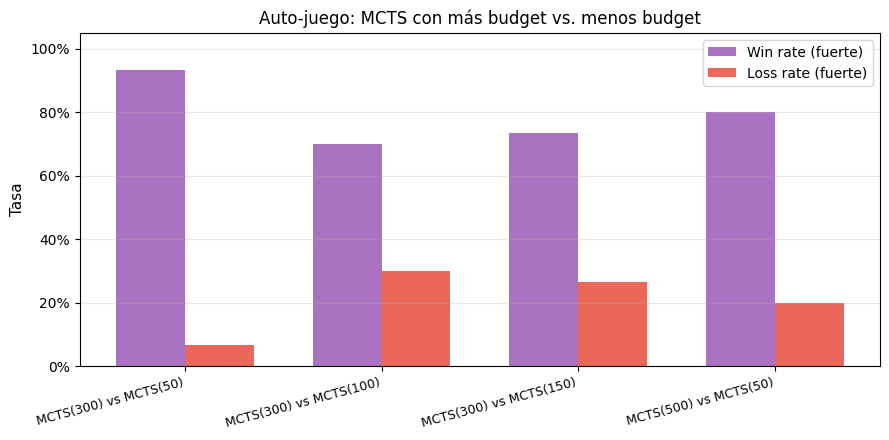

Figura 3 guardada


In [9]:
labels   = [r['label'] for r in self_results]
wr_strong = [r['win_rate']  for r in self_results]
lr_weak   = [r['loss_rate'] for r in self_results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width/2, wr_strong, width, label='Win rate (fuerte)', color='#9b59b6', alpha=0.85)
ax.bar(x + width/2, lr_weak,   width, label='Loss rate (fuerte)', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Tasa', fontsize=11)
ax.set_title('Auto-juego: MCTS con más budget vs. menos budget', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig3_self_play.png', dpi=150)
plt.show()
print("Figura 3 guardada")


## 6. Experimento 4 — Tiempo de decisión vs. budget

Análisis del costo computacional. Importante para entender la limitación real del agente.


budget=  10 → 0.019s por movimiento
budget=  30 → 0.040s por movimiento
budget=  75 → 0.106s por movimiento
budget= 150 → 0.213s por movimiento
budget= 300 → 0.446s por movimiento
budget= 500 → 0.652s por movimiento


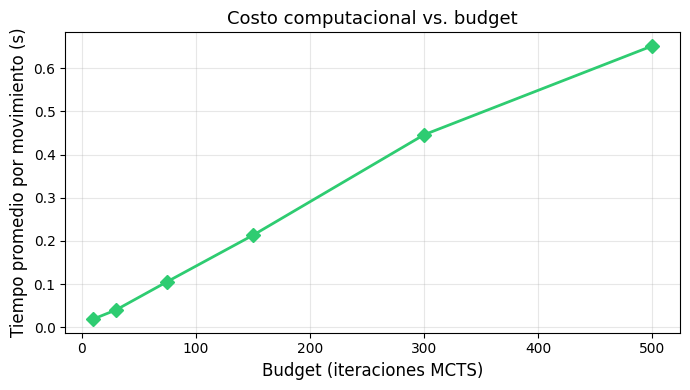

In [10]:
budgets_time = [10, 30, 75, 150, 300, 500]
times = []

board = np.zeros((6,7), dtype=int)
for b in budgets_time:
    agent = MCTry(budget=b)
    t0 = time.time()
    for _ in range(5):
        agent.act(board)
    times.append((time.time()-t0)/5)
    print(f"budget={b:4d} → {times[-1]:.3f}s por movimiento")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(budgets_time, times, 'D-', color='#2ecc71', linewidth=2, markersize=7)
ax.set_xlabel('Budget (iteraciones MCTS)', fontsize=12)
ax.set_ylabel('Tiempo promedio por movimiento (s)', fontsize=12)
ax.set_title('Costo computacional vs. budget', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_time_vs_budget.png', dpi=150)
plt.show()


## 7. Conclusiones

### Rendimiento
- **Flat MC** ya gana >95% al aleatorio con 50 simulaciones en ambos colores.
- **MCTS** alcanza el mismo umbral con un budget de ~75 iteraciones y es más robusto
  porque el árbol **reutiliza información** entre simulaciones (a diferencia de Flat MC que
  estima cada columna de forma independiente).
- En auto-juego, un agente con más budget vence consistentemente al de menos budget,
  lo que confirma que el budget mide calidad de estrategia, no solo win rate contra el aleatorio.

### Debilidades identificadas
1. **Horizonte corto**: Con presupuesto bajo el árbol no se profundiza suficiente;
   el agente puede perder ante secuencias de amenazas en 2 pasos (fork attacks).
2. **Sin reutilización del árbol entre turnos**: El árbol se construye desde cero en cada
   movimiento. Reutilizar el subárbol del movimiento anterior cuadruplicaría la profundidad
   efectiva sin costo extra.
3. **Rollouts aleatorios**: Los rollouts no tienen heurística de dominio (p.ej. preferir
   columna central). Rollouts dirigidos mejorarían la calidad de las estimaciones.

### Propuestas para versión futura
- **Tree reuse entre turnos**: guardar el subárbol del movimiento elegido y reutilizarlo.
- **Rollouts semi-aleatorios**: incorporar una pequeña heurística posicional (peso central)
  sin romper la base teórica FVMC.
- **RAVE (Rapid Action Value Estimation)**: actualizar todos los nodos que usaron la misma
  acción en un rollout, no solo los de la trayectoria actual.


## 8. Agente final exportado

In [11]:
# The final agent for the tournament is MCTry(budget=300)
# It's saved as policy.py in this folder
final_agent = MCTry(budget=300)
r_red    = play_games(final_agent, random_agent, n_games=50, agent_color=-1)
r_yellow = play_games(final_agent, random_agent, n_games=50, agent_color=1)
print(f"Agente final MCTry(budget=300):")
print(f"  Como Rojo:     {r_red['win_rate']:.0%} wins ({r_red['wins']}/50)")
print(f"  Como Amarillo: {r_yellow['win_rate']:.0%} wins ({r_yellow['wins']}/50)")


Agente final MCTry(budget=300):
  Como Rojo:     100% wins (50/50)
  Como Amarillo: 100% wins (50/50)
